In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00121
00121


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]
elif case[3] == '3':
    cntrl_vars_init = [0]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)
elif case[3] == '4':
    cntrl_vars_init = [1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)
elif case[3] == '5':
    cntrl_vars_init = [0,1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 5
i_range = range(0, len(exc),i_stepsize)
i_range_0 = range(0, len(exc),i_stepsize)
i_range_1 = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.750000000000000

In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.289828199723
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9111.456490210901
Gradient descend method:  None
RUN  0 , total integrated cost =  9111.456490210901
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  15 0.4500000000000001 0.4500000000000002

In [14]:
factor_iteration = 20.
aln.params.duration = dur

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    ##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if conv_init[i] == [True, True]:
    
        with open(read_file,'rb') as f:
            load_array = pickle.load(f)

        bestControl_read = load_array[0]

        bestControl_init[i] = np.zeros(( 1, 6, n_dur + n_pre + n_post -2 ))
        bestControl_init[i][:,:,n_pre-1:n_pre-1+1000] = bestControl_read[i][:,:,n_pre-1:n_pre-1+1000].copy()
        
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]
                
        cost.setParams(weights_init[i][0], weights_init[i][1], weights_init[i][2])

        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        
        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = 0, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        continue
    
    aln.params.duration = dur
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9111.456490210901
Gradient descend method:  None
RUN  1 , total integrated cost =  777.7450427577537
RUN  2 , total integrated cost =  86.36545663451056
RUN  3 , total integrated cost =  75.64446597046592
RUN  4 , total integrated cost =  73.36574936992183
RUN  5 , total integrated cost =  71.45963054358768
RUN  6 , total integrated cost =  70.15208523688104
RUN  7 , total integrated cost =  68.80448498521586
RUN  8 , total integrated cost =  67.62836341538993
RUN  9 , total integrated cost =  66.47023657823841
RUN  10 , total integrated cost =  65.57554713333734
RUN  11 , total integrated cost =  64.61035744508986
RUN  12 , total integrated cost =  63.850498937705666
RUN  13 , total integrated cost =  63.10192720462361
RUN  14 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  615 , total integrated cost =  29.871940393657976
Improved over  615  iterations in  97.93624925427139  seconds by  99.67214966755587  percent.
Problem in initial value trasfer:  Vmean_exc -56.6465148028947 -56.64651481897037
weight =  3050.172292170658
set cost params:  1.0 0.0 3050.172292170658
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9098.792818274305
Gradient descend method:  None
RUN  1 , total integrated cost =  8714.608738350797
RUN  2 , total integrated cost =  8697.497394085582
RUN  3 , total integrated cost =  8685.147442184216
RUN  4 , total integrated cost =  8573.636819526704
RUN  5 , total integrated cost =  8559.268132027522
RUN  6 , total integrated cost =  8529.817985791607
RUN  7 , total integrated cost =  8498.0142072436
RUN  8 , total integrated cost =  8495.982203271436
RUN  9 , total integrated cost =  8490.591587126606
RUN  10 , total integrated cost =  8487.678815221998
RUN  11 , total integrat

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  353 , total integrated cost =  7558.357084881997
Improved over  353  iterations in  82.33182858489454  seconds by  16.93011110549135  percent.
Problem in initial value trasfer:  Vmean_exc -56.645595666854916 -56.645610944868096
-------  15 0.4500000000000001 0.4500000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13018.074640346456
Gradient descend method:  None
RUN  1 , total integrated cost =  752.0306909948858
RUN  2 , total integrated cost =  51.46480468785491
RUN  3 , total integrated cost =  47.774091249177324
RUN  4 , total integrated cost =  47.3023226499911
RUN  5 , total integrated cost =  47.15915003234822
RUN  6 , total integrated cost =  47.04594333061501
RUN  7 , total integrated cost =  46.92185160779853
RUN  8 , total integrated cost =  46.82569030742813
RUN  9 , total integrated cost =  46.72513986526382
RUN  10 , total integrated cost =  46.61818314920936
RUN  11 , 

...

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  161 , total integrated cost =  32648.315217401916
Improved over  161  iterations in  58.797296814620495  seconds by  3.6594631053777533  percent.
Problem in initial value trasfer:  Vmean_exc -56.70334373013854 -56.703343717159136
-------  110 0.5000000000000002 0.8000000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19226.098318201533
Gradient descend method:  None
RUN  1 , total integrated cost =  19226.098318201533
Control only changes marginally.
RUN  1 , total integrated cost =  19226.098318201533
Improved over  1  iterations in  0.3775282949209213  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19226.098318201533
Gradient descend method:  None
RUN  1 , total integrated cost =  19226.098318201533
Control only changes marginally.
RUN  1 , total integrated cost =  19226.098318201533
Imp

RUN  1 , total integrated cost =  14547.979043359295
Control only changes marginally.
RUN  1 , total integrated cost =  14547.979043359295
Improved over  1  iterations in  0.34192637726664543  seconds by  0.0  percent.
-------  130 0.6000000000000003 0.8500000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38727.35641379273
Gradient descend method:  None
RUN  1 , total integrated cost =  958.9660748736435
RUN  2 , total integrated cost =  745.6253779356662
RUN  3 , total integrated cost =  154.19328414776018
RUN  4 , total integrated cost =  89.80919265212609
RUN  5 , total integrated cost =  53.85877961025514
RUN  6 , total integrated cost =  37.51972284772974
RUN  7 , total integrated cost =  33.98717687331713
RUN  8 , total integrated cost =  32.88771542857579
RUN  9 , total integrated cost =  32.329290462496544
RUN  10 , total integrated cost =  31.942805043697756
RUN  11 , total integrated cost =  31.63320462130703
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  513 , total integrated cost =  38044.77939194422
Improved over  513  iterations in  191.09514792449772  seconds by  1.7579581590343167  percent.
Problem in initial value trasfer:  Vmean_exc -56.700187187873254 -56.70018717298648
-------  135 0.5250000000000001 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.636143093983
Control only changes marginally.
RUN  1 , total integrated cost =  23532.636143093983
Improved over  1  iterations in  0.39564318768680096  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.636143093983
Control only changes marginally.
RUN  1 , total integrated cost =  23532.636143093983
Imp

--------- 0


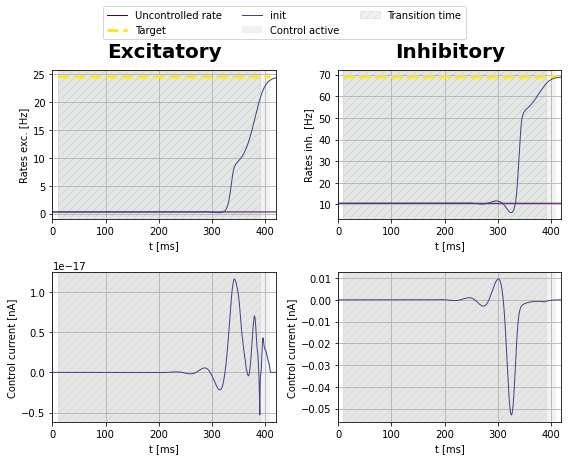

--------- 5


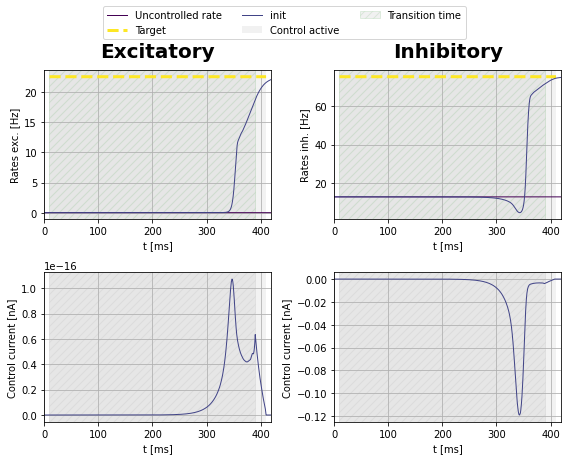

--------- 10


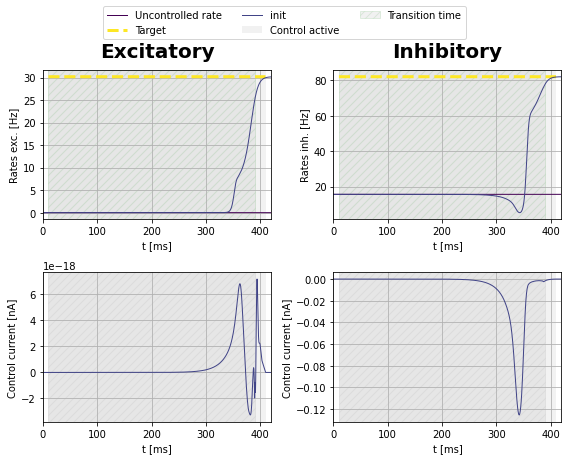

--------- 15


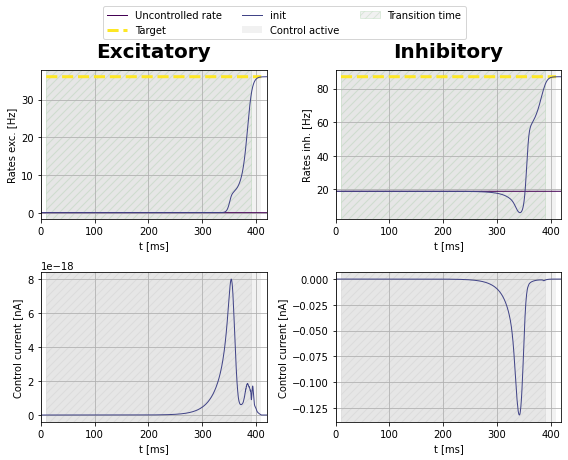

--------- 20


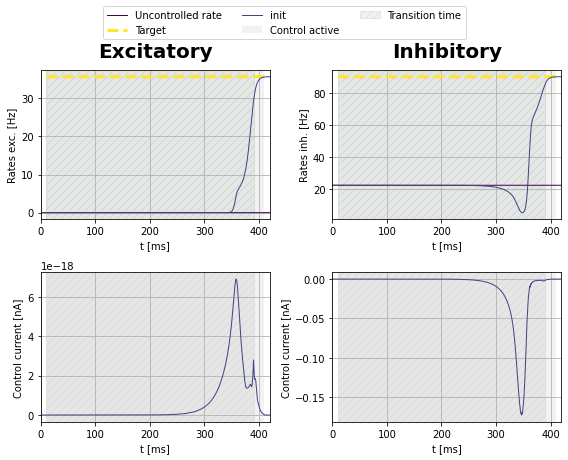

--------- 25


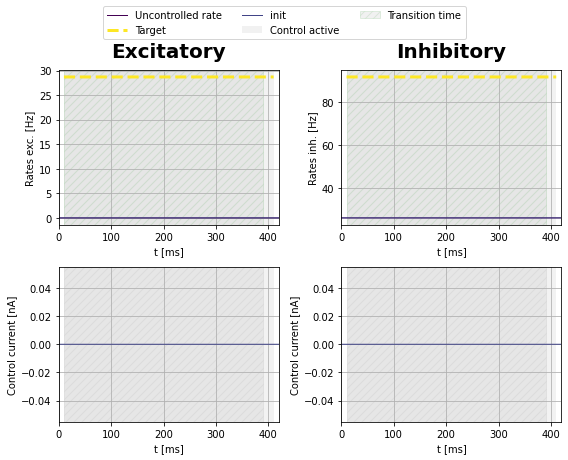

--------- 30


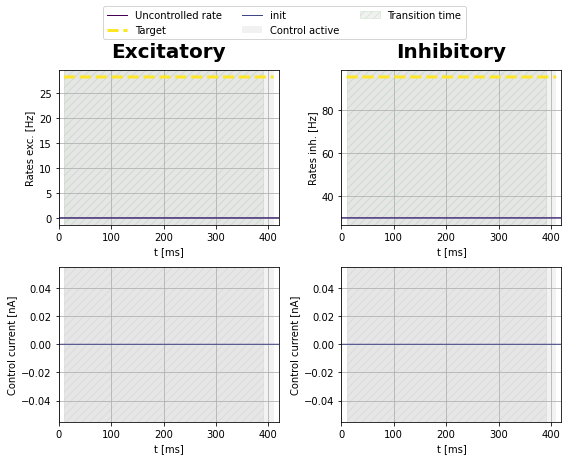

--------- 35


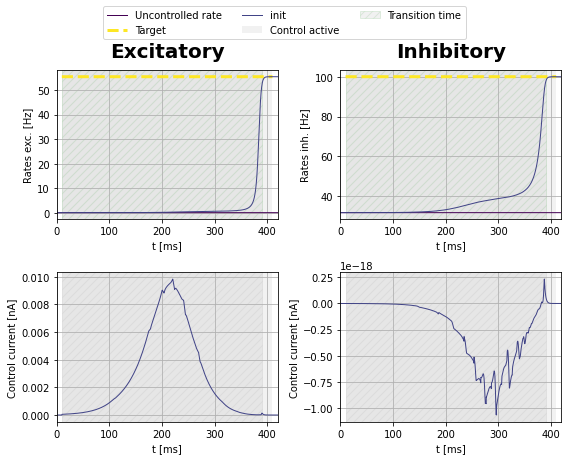

--------- 40


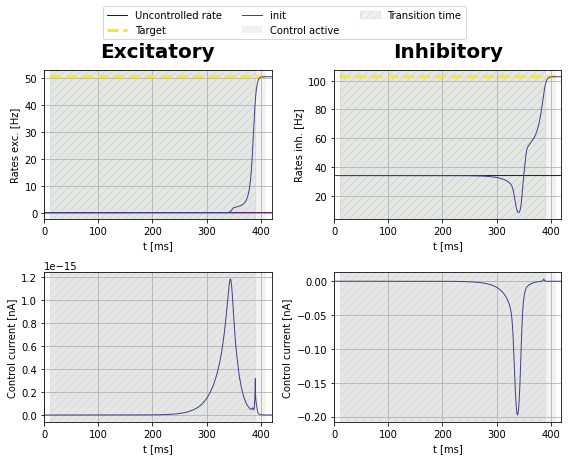

--------- 45


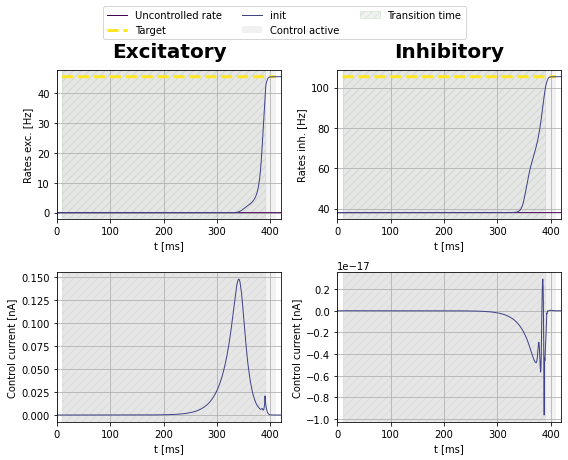

--------- 50


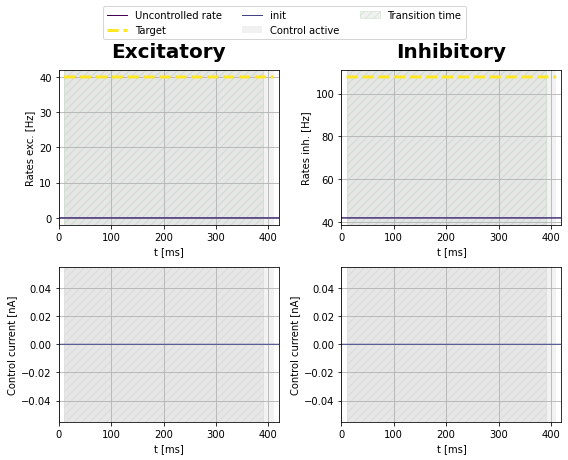

--------- 55


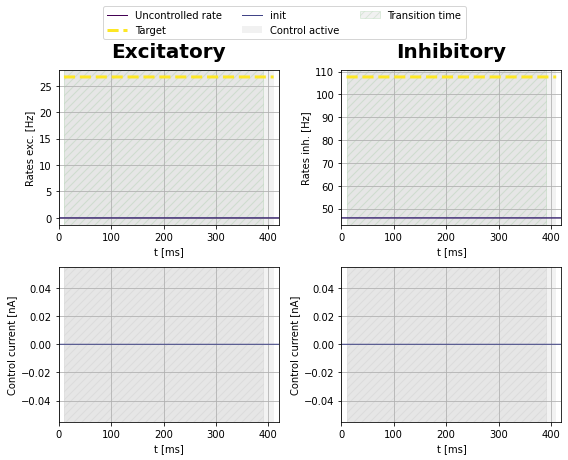

--------- 60


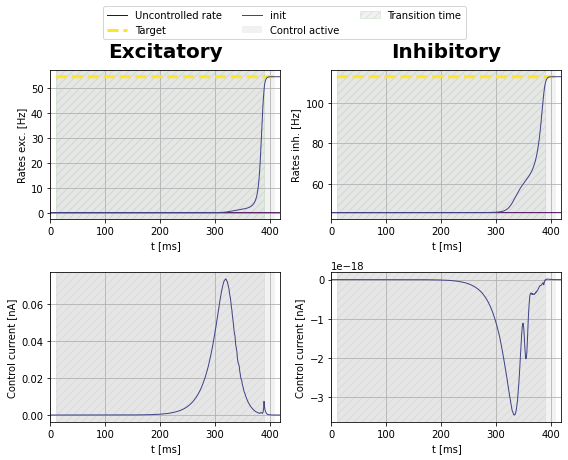

--------- 65


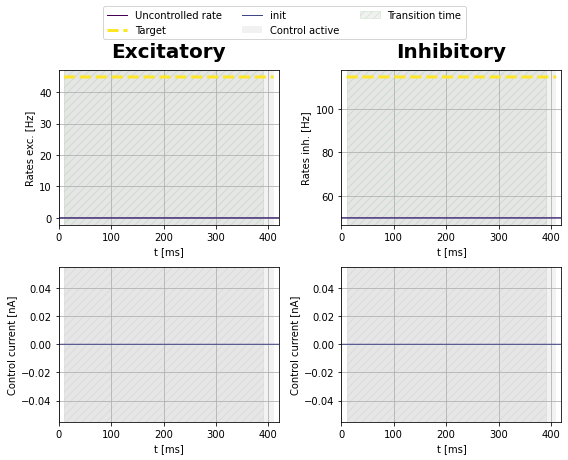

--------- 70


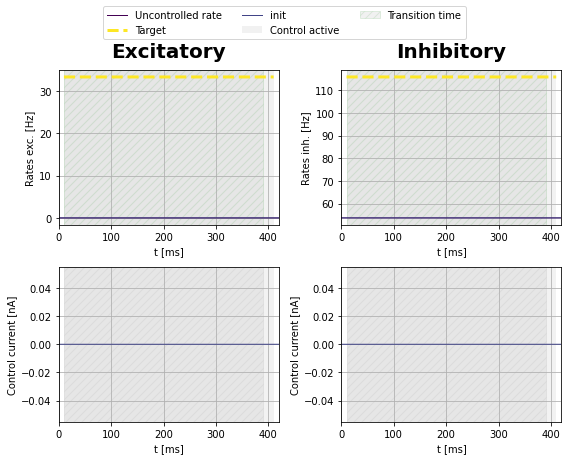

--------- 75


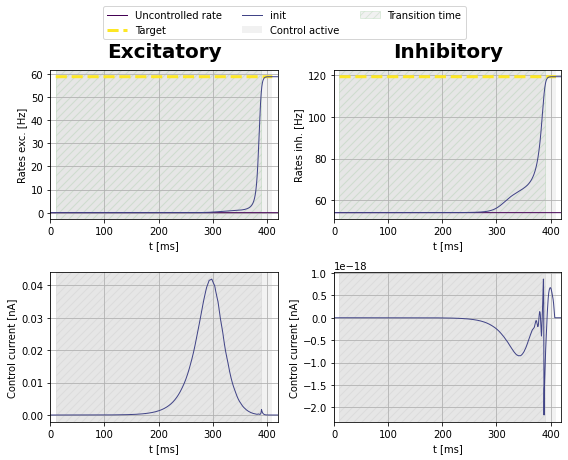

--------- 80


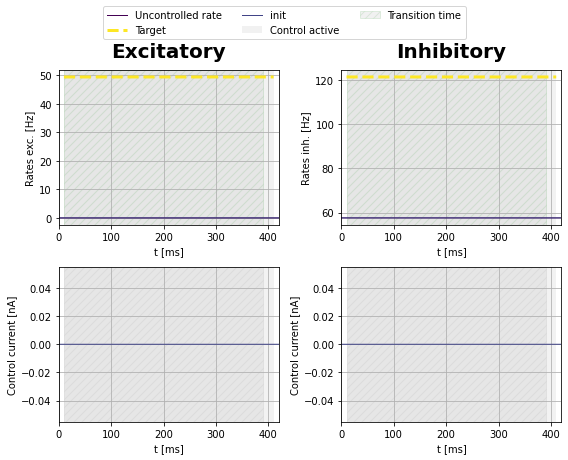

--------- 85


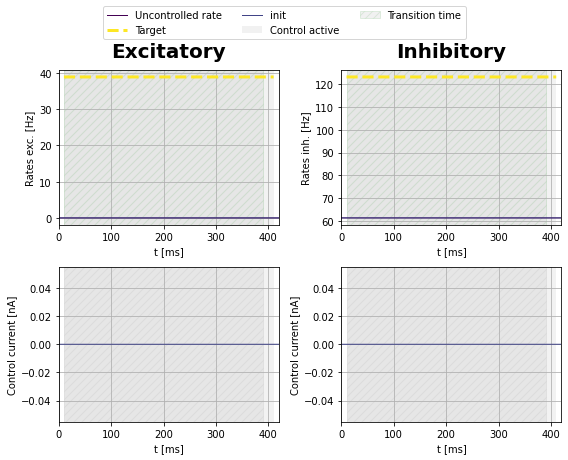

--------- 90


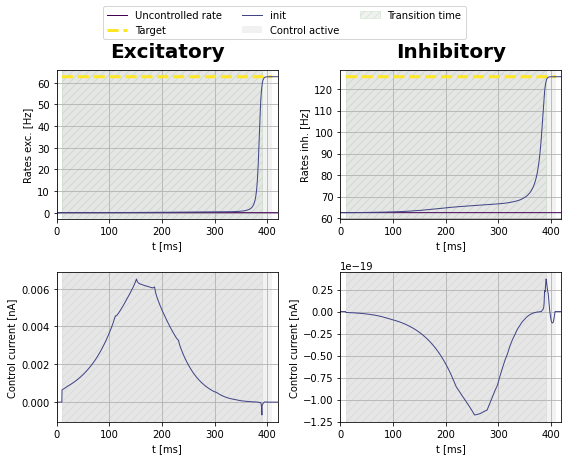

--------- 95


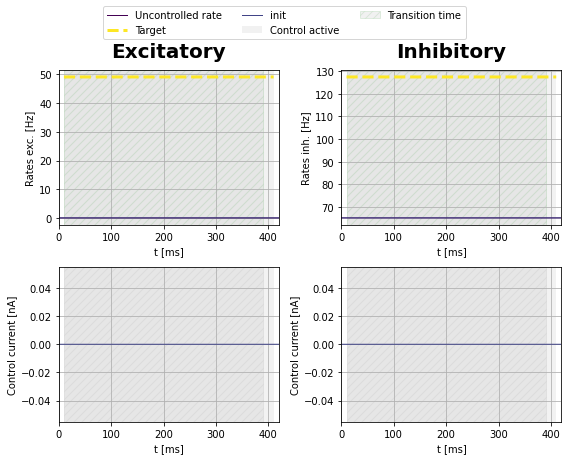

--------- 100


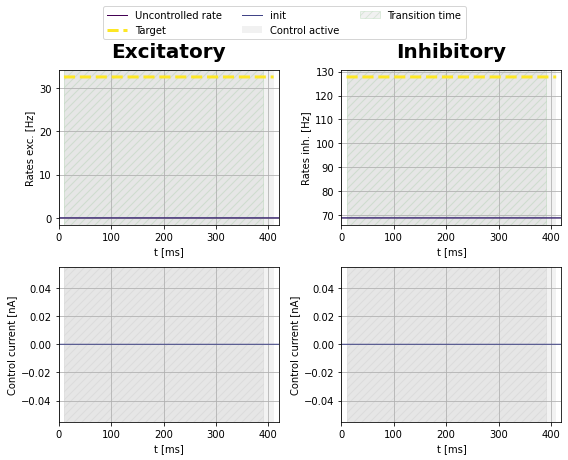

--------- 105


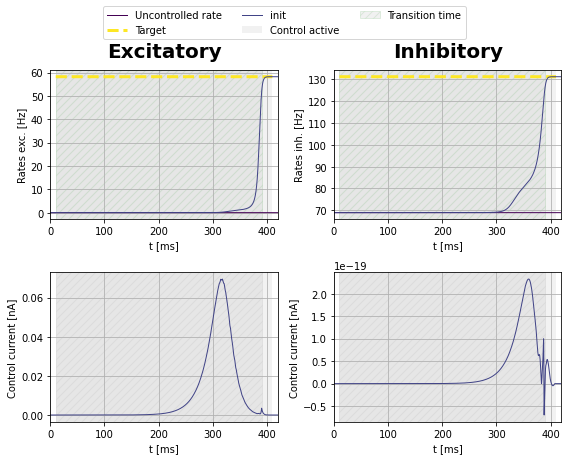

--------- 110


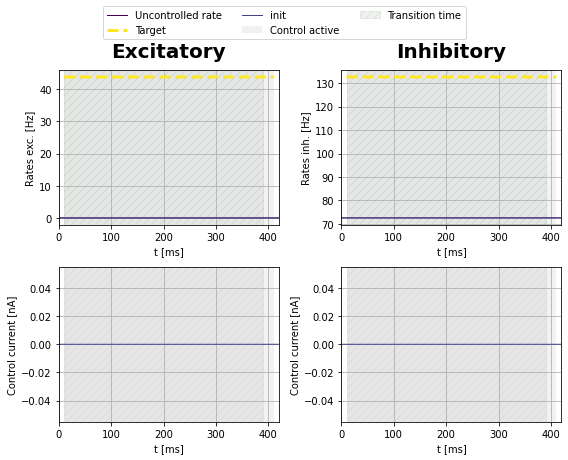

--------- 115


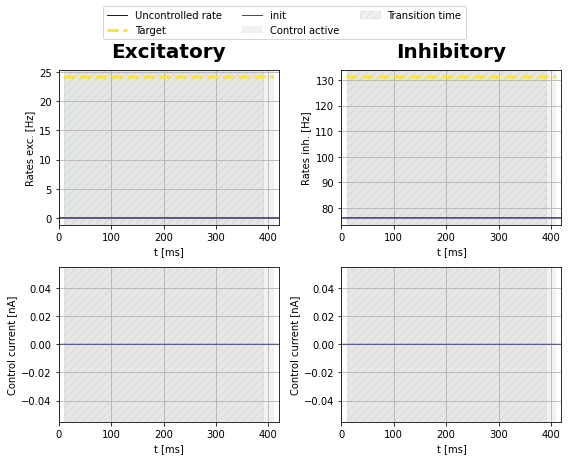

--------- 120


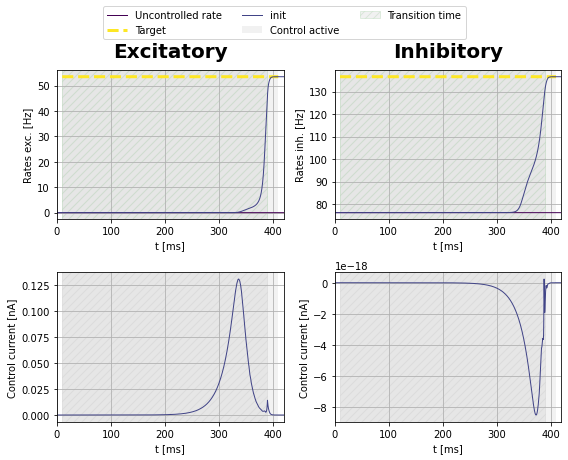

--------- 125


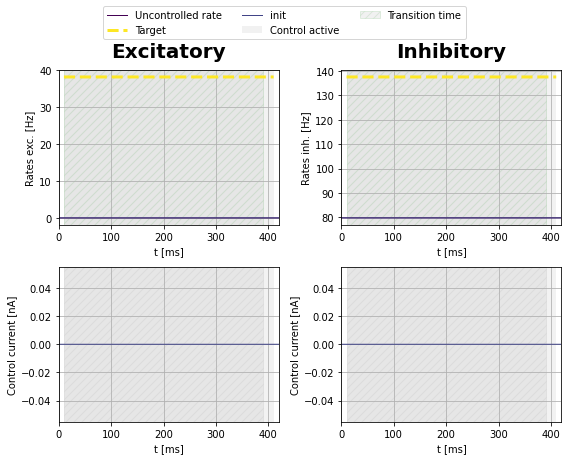

--------- 130


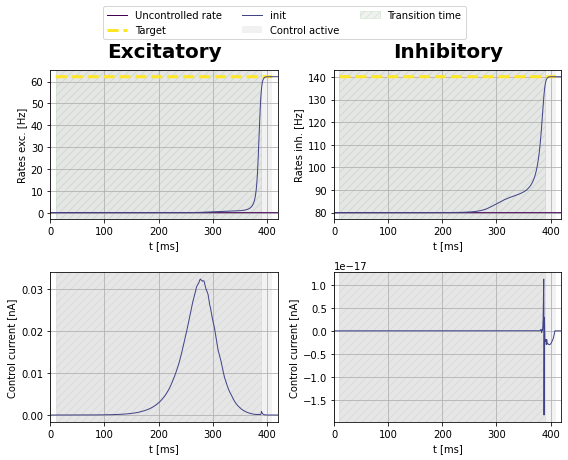

--------- 135


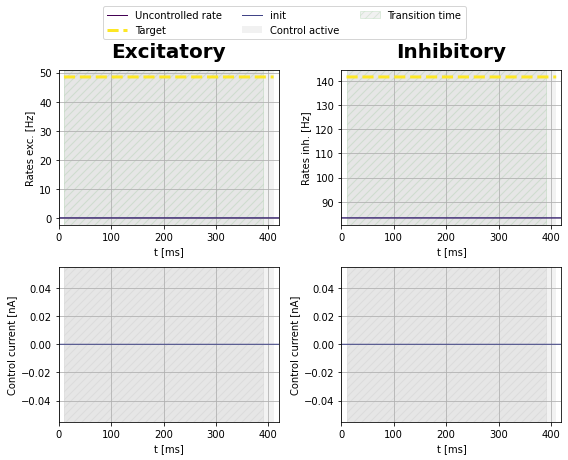

--------- 140


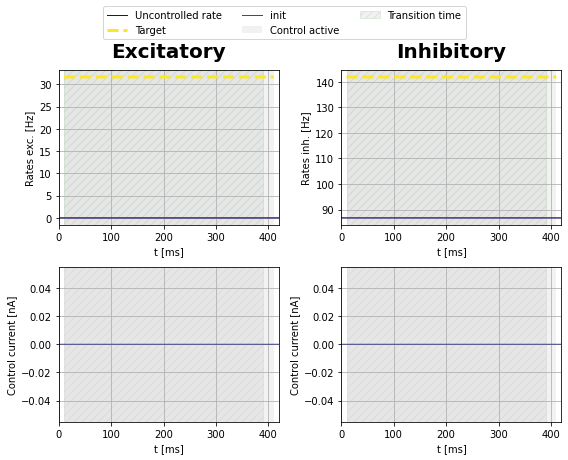

--------- 145


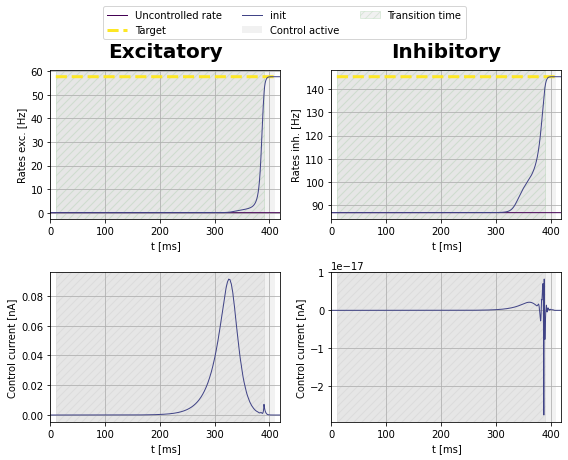

In [15]:

#plot initial guesses
for i in i_range:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [16]:
found_solution = []
no_solution = []
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])    


    if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.1 * np.abs(
        np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
        np.mean(bestState_init[i][0,1,-300:]) - target[i][0,1,-1]) < 0.1 * np.abs(
        np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amax(
        bestState_init[i][0,0,:]) < target[i][0,0,-1] + 5. and np.amax(
        bestState_init[i][0,1,:]) < target[i][0,1,-1] + 5.:
        # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
        #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
        if i not in found_solution:
            print("found solution for ", i)
            found_solution.append(i)
        if i in no_solution:
            no_solution.pop(no_solution.index(i))
        

-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  5 0.4000000000000001 0.40000000000000013
found solution for  5
-------  10 0.4250000000000001 0.42500000000000016
found solution for  10
-------  15 0.4500000000000001 0.4500000000000002
found solution for  15
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
found solution for  35
-------  40 0.5250000000000001 0.5500000000000003
found solution for  40
-------  45 0.5000000000000002 0.5750000000000003
found solution for  45
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
found solution for  60
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.67500000000

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [18]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  6039.132763259188
set cost params:  1.0 0.0 6039.132763259188
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5884.034137294422
Gradient descend method:  None
RUN  1 , total integrated cost =  5881.801768252664
RUN  2 , total integrated cost =  5881.798119922672
RUN  3 , total integrated cost =  5881.797922090412
RUN  4 , total integrated cost =  5881.797901234745
RUN  5 , total integrated cost =  5881.797897801604

ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  5881.797896978736
Control only changes marginally.
RUN  16 , total integrated cost =  5881.797896978736
Improved over  16  iterations in  5.1473705265671015  seconds by  0.03800522334688594  percent.
Problem in initial value trasfer:  Vmean_exc -56.62658401897052 -56.62659208966847
no convergence
-------  5 0.4000000000000001 0.40000000000000013
weight =  2129.744732765571
set cost params:  1.0 0.0 2129.744732765571
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5093.368171103077
Gradient descend method:  None
RUN  1 , total integrated cost =  5093.3576098443355
RUN  2 , total integrated cost =  5093.357296724491
RUN  3 , total integrated cost =  5093.357247192442
RUN  4 , total integrated cost =  5093.357233984323
RUN  5 , total integrated cost =  5093.357229621136
RUN  6 , total integrated cost =  5093.357228166777
RUN  7 , total integrated cost =  5093.357227562284
RUN  8 , total integrated cost =  5093.357227316932
RUN  9 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  26 , total integrated cost =  5093.357227133984
Improved over  26  iterations in  7.953478399664164  seconds by  0.00021486703344919533  percent.
Problem in initial value trasfer:  Vmean_exc -56.62533436382399 -56.62531683321051
no convergence
-------  10 0.4250000000000001 0.42500000000000016
weight =  3675.9250004538108
set cost params:  1.0 0.0 3675.9250004538108
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9099.004503061438
Gradient descend method:  None
RUN  1 , total integrated cost =  9098.33757024839
RUN  2 , total integrated cost =  9098.336579740802
RUN  3 , total integrated cost =  9098.336471028852
RUN  4 , total integrated cost =  9098.336431427771
RUN  5 , total integrated cost =  9098.336396453982
RUN  6 , total integrated cost =  9098.33637463251
RUN  7 , total integrated cost =  9098.336354566438
RUN  8 , total integrated cost =  9098.336338023693
RUN  9 , total integrated cost =  9098.336322180818
RUN  1

...

RUN  1 , total integrated cost =  9108.98145522385
Control only changes marginally.
RUN  1 , total integrated cost =  9108.98145522385
Improved over  1  iterations in  0.5071829445660114  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64550122885649 -56.645518070339335
converged for  10
-------  15 0.4500000000000001 0.4500000000000002
weight =  5039.535252030723
set cost params:  1.0 0.0 5039.535252030723
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13015.491963311277
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13015.491963311277
Control only changes marginally.
RUN  1 , total integrated cost =  13015.491963311277
Improved over  1  iterations in  0.513982554897666  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67041015991127 -56.670416420928056
converged for  15
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.4750000000000001

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  9108.981455223953
Control only changes marginally.
RUN  1 , total integrated cost =  9108.981455223953
Improved over  1  iterations in  0.5069772507995367  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64550122885649 -56.645518070339335
converged for  10
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 

In [19]:
"""
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
"""

'\nfor i in i_range_0:\n    \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],\n        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n'

In [20]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [ ]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  60.42239712353589
Gradient descend method:  None
RUN  1 , total integrated cost =  1.1038008983246923
RUN  2 , total integrated cost =  1.086587025361926
RUN  3 , total integrated cost =  1.0783729199585848
RUN  4 , total integrated cost =  1.0735832657341489
RUN  5 , total integrated cost =  1.0713185372593985
RUN  6 , total integrated cost =  1.0

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1560 , total integrated cost =  2.4605594318180826
Improved over  1560  iterations in  201.42108593136072  seconds by  95.56001581748897  percent.
Problem in initial value trasfer:  Vmean_exc -56.62446684010046 -56.62446682182784
no convergence
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  59.38527694677088
Gradient descend method:  None
RUN  1 , total integrated cost =  2.648078790130827
RUN  2 , total integrated cost =  2.625458470063212
RUN  3 , total integrated cost =  2.619383617650738
RUN  4 , total integrated cost =  2.615320095025744
RUN  5 , total integrated cost =  2.5944604989358924
RUN  6 , total integrated cost =  2.5837196791008297
RUN  7 , total integrated cost =  2.582244326086142
RUN  8 , total integrated cost =  2.58124799922047
RUN  9 , total integrated cost =  2.580569857126988
RUN  10 , total integrated cost =  2.578567017

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1146 , total integrated cost =  2.5773994980157227
Improved over  1146  iterations in  166.58266594819725  seconds by  95.41698055205892  percent.
Problem in initial value trasfer:  Vmean_exc -56.67067491750871 -56.67067489825252
no convergence
-------  20 0.4500000000000001 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  64.84407783139461
Gradient descend method:  None
RUN  1 , total integrated cost =  3.59431217726365
RUN  2 , total integrated cost =  3.577722441260068
RUN  3 , total integrated cost =  3.566247078345416
RUN  4 , total integrated cost =  3.559287616163541
RUN  5 , total integrated cost =  3.5555882159623446
RUN  6 , total integrated cost =  3.5528996606088854
RUN  7 , total integrated cost =  3.5457005524697904
RUN  8 , total integrated cost =  3.541442754193208
RUN  9 , total integrated cost =  3.539207361020504
RUN  10 , total integrated cost =  3.537532606

no convergence
-------  40 0.5250000000000001 0.5500000000000003
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  60.39634468762331
Gradient descend method:  None
RUN  1 , total integrated cost =  3.402240715063512
RUN  2 , total integrated cost =  3.3888901858983944
RUN  3 , total integrated cost =  3.3827809857988322
RUN  4 , total integrated cost =  3.3802533390209697
RUN  5 , total integrated cost =  3.3786164406651893
RUN  6 , total integrated cost =  3.376937113348226
RUN  7 , total integrated cost =  3.375666454762909
RUN  8 , total integrated cost =  3.3728125909975963
RUN  9 , total integrated cost =  3.3714137034346128
RUN  10 , total integrated cost =  3.370783771070207
RUN  11 , total integrated cost =  3.370301497961989
RUN  12 , total integrated cost =  3.369666702381725
RUN  13 , total integrated cost =  3.3691848996868914
RUN  14 , total integrated cost =  3.368532401439017
RUN  15 , total integrated cost =  3.3680049

RUN  17 , total integrated cost =  2.1314709928479534
RUN  18 , total integrated cost =  2.1304275422091137
RUN  19 , total integrated cost =  2.129404905029528
RUN  20 , total integrated cost =  2.128465255123744
RUN  30 , total integrated cost =  2.121159398338313
RUN  40 , total integrated cost =  2.115274463044754
RUN  50 , total integrated cost =  2.1098197091165884
RUN  60 , total integrated cost =  2.1067886881483524
RUN  70 , total integrated cost =  2.104549995680864
RUN  80 , total integrated cost =  2.1044587105562167
RUN  90 , total integrated cost =  2.1038405686100945
RUN  100 , total integrated cost =  2.1035992642895556
RUN  110 , total integrated cost =  2.103542912213557
RUN  120 , total integrated cost =  2.1034662077883826
RUN  130 , total integrated cost =  2.1034451038097943
RUN  140 , total integrated cost =  2.1034309853769906
RUN  150 , total integrated cost =  2.1034116726840564
RUN  160 , total integrated cost =  2.1033952906852056
RUN  170 , total integrated

RUN  16 , total integrated cost =  244.39049363821977
RUN  17 , total integrated cost =  215.66184787669488
RUN  18 , total integrated cost =  190.1922082214072
RUN  19 , total integrated cost =  169.43324152996246
RUN  20 , total integrated cost =  151.34316999951835
RUN  30 , total integrated cost =  63.902479866852694
RUN  40 , total integrated cost =  34.0681491680519
RUN  50 , total integrated cost =  17.04958312110926
RUN  60 , total integrated cost =  13.48685059160426
RUN  70 , total integrated cost =  11.33424046102908
RUN  80 , total integrated cost =  10.496728511616592
RUN  90 , total integrated cost =  9.84408733350493
RUN  100 , total integrated cost =  9.33434956481203
RUN  110 , total integrated cost =  8.952423758141862
RUN  120 , total integrated cost =  8.626400904339583
RUN  130 , total integrated cost =  8.311619983146166
RUN  140 , total integrated cost =  8.018943434972046
RUN  150 , total integrated cost =  7.755023483953021
RUN  160 , total integrated cost =  7

RUN  9 , total integrated cost =  2.044634555357792
RUN  10 , total integrated cost =  2.04374318562966
RUN  11 , total integrated cost =  2.043041183156693
RUN  12 , total integrated cost =  2.042394317888038
RUN  13 , total integrated cost =  2.0419339165967054
RUN  14 , total integrated cost =  2.041478414339354
RUN  15 , total integrated cost =  2.041179695914299
RUN  16 , total integrated cost =  2.0409193021844696
RUN  17 , total integrated cost =  2.0407393258132265
RUN  18 , total integrated cost =  2.0406087228512475
RUN  19 , total integrated cost =  2.040507771740735
RUN  20 , total integrated cost =  2.040443843712313
RUN  30 , total integrated cost =  2.0398812494504384
RUN  40 , total integrated cost =  2.0396471454687686
RUN  50 , total integrated cost =  2.038072979914853
RUN  60 , total integrated cost =  2.037982661552019
RUN  70 , total integrated cost =  2.037875568571017
RUN  80 , total integrated cost =  2.037846092557734
RUN  90 , total integrated cost =  2.03779

converged for  125
-------  130 0.6000000000000003 0.8500000000000005
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16.50986941553554
Gradient descend method:  None
RUN  1 , total integrated cost =  1.1252805068441258
RUN  2 , total integrated cost =  1.1250872920284676
RUN  3 , total integrated cost =  1.1249305441928945
RUN  4 , total integrated cost =  1.1248019147758095
RUN  5 , total integrated cost =  1.124673202927376
RUN  6 , total integrated cost =  1.1245816038543648
RUN  7 , total integrated cost =  1.1244524908217994
RUN  8 , total integrated cost =  1.1243823723674782
RUN  9 , total integrated cost =  1.124288620714944
RUN  10 , total integrated cost =  1.1242327392764442
RUN  11 , total integrated cost =  1.1241906450285917
RUN  12 , total integrated cost =  1.1241553351589364
RUN  13 , total integrated cost =  1.1241507741165995
RUN  14 , total integrated cost =  1.1241447997378473
RUN  15 , total integrated cost = 